# Peptide Location Analysis

Recover the peptide classification and sequence-matching workflow for signal peptide, canonical, and noncanonical peptides.

In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns


In [2]:
project_dir = 'D:/Projects/ehlastic_release'
data_dir = os.path.join(project_dir, 'data')
fig_dir = os.path.join(project_dir, 'figure', 'Fig_Location')
os.makedirs(fig_dir, exist_ok=True)

fasta_path = os.path.join(data_dir, 'Protein_Database', '20251201_JURKAT_HLA_SP_PA.fa')

In [3]:
records = []
accession = None
sequence_parts = []

with open(fasta_path, 'r', encoding='utf-8') as handle:
    for raw_line in handle:
        line = raw_line.strip()
        if not line:
            continue
        if line.startswith('>'):
            if accession is not None:
                records.append({
                    'Accession': accession,
                    'Sequence': ''.join(sequence_parts),
                })
            accession = line[1:].strip().split()[0]
            sequence_parts = []
        else:
            sequence_parts.append(line)

if accession is not None:
    records.append({
        'Accession': accession,
        'Sequence': ''.join(sequence_parts),
    })

fasta_df = pd.DataFrame(records, columns=['Accession', 'Sequence'])
fasta_df = fasta_df.loc[~fasta_df['Accession'].str.startswith('HLA', na=False)].reset_index(drop=True)
fasta_df['pep_type'] = pd.NA
fasta_df.loc[fasta_df['Accession'].str.startswith('sp', na=False), 'pep_type'] = 'canonical'
fasta_df.loc[fasta_df['Accession'].str.startswith('CONTRIB_GENCODE_', na=False), 'pep_type'] = 'noncanonical'
fasta_df['Accession'] = fasta_df['Accession'].str.replace('CONTRIB_GENCODE_', '', regex=False)

fasta_df['pep_type'].value_counts(dropna=False)

pep_type
canonical       20376
noncanonical     7264
Name: count, dtype: int64

## Figure: Peptide Locations Within Precursor Proteins / ORFs

Regenerate the three-panel summary figure using the per-category match dictionaries built above:
- **(a)** horizontal bars showing each match's peptide span on top of the full precursor length (log-scale residue position),
- **(b)** distance from the nearest terminus (residues, log scale), and
- **(c)** relative start position normalised to the precursor length.

In [4]:
# `hla_df['Sequence']` only stores the ~24-residue signal peptide, but the biological
# precursor is the full HLA class I molecule (~365 residues). Use the full-length
# protein for position math so signal peptides correctly land at the N-terminus.
HLA_FALLBACK_PRECURSOR_LENGTH = 365
hla_full_fasta_path = os.path.join(data_dir, 'IMGT_HLA', 'hla_prot.fasta')

allele_to_full_length = {}
if os.path.exists(hla_full_fasta_path):
    cur_alleles, cur_seq = [], []
    def _flush(alleles, seq_parts):
        if not alleles:
            return
        seq_len = len(''.join(seq_parts))
        for a in alleles:
            allele_to_full_length.setdefault(a, seq_len)
    with open(hla_full_fasta_path, 'r', encoding='utf-8') as handle:
        for raw in handle:
            line = raw.strip()
            if not line:
                continue
            if line.startswith('>'):
                _flush(cur_alleles, cur_seq)
                # header looks like '>HLA:HLA00001 A*01:01:01:01 365 bp'
                parts = line[1:].split()
                cur_alleles = [parts[1]] if len(parts) >= 2 else []
                cur_seq = []
            else:
                cur_seq.append(line)
        _flush(cur_alleles, cur_seq)


def _hla_precursor_length(accession):
    """Look up full HLA precursor length for an `hla_df` accession like 'loc1|A*01:472'.

    Walks down allele-resolution levels (`A*01:472` -> `A*01`) and falls back to the
    canonical class I length when nothing matches.
    """
    if accession is None or pd.isna(accession):
        return HLA_FALLBACK_PRECURSOR_LENGTH
    allele = accession.split('|')[-1]
    if allele in allele_to_full_length:
        return allele_to_full_length[allele]
    fields = allele.split(':')
    while len(fields) > 1:
        fields = fields[:-1]
        prefix = ':'.join(fields)
        for k, v in allele_to_full_length.items():
            if k == prefix or k.startswith(prefix + ':'):
                return v
    # Final fallback: median across known class I alleles, else 365.
    if allele_to_full_length:
        return int(np.median(list(allele_to_full_length.values())))
    return HLA_FALLBACK_PRECURSOR_LENGTH


def _records_from_match_dict(match_dict, category):
    rows = []
    for peptide, matches_df in match_dict.items():
        if matches_df is None or len(matches_df) == 0:
            rows.append({
                'peptide': peptide,
                'category': category,
                'accession': None,
                'protein_length': np.nan,
                'start': np.nan,
                'end': np.nan,
                'has_match': False,
            })
            continue
        for _, m in matches_df.iterrows():
            if category == 'signal peptide':
                protein_length = _hla_precursor_length(m['Accession'])
            else:
                protein_length = len(m['Sequence'])
            rows.append({
                'peptide': peptide,
                'category': category,
                'accession': m['Accession'],
                'protein_length': protein_length,
                'start': int(m['start']),
                'end': int(m['end']),
                'has_match': True,
            })
    return rows


heatmap_category_rank = {
    'signal peptide': 0,
    'canonical': 1,
    'noncanonical': 2,
}

heatmap_group_to_category = {
    'signal_peptide': 'signal peptide',
    'other_canonical': 'canonical',
    'noncanonical': 'noncanonical',
}
heatmap_category_rank = {
    'signal peptide': 0,
    'canonical': 1,
    'noncanonical': 2,
}


matches_df = pd.read_csv(os.path.join(data_dir, 'Table_for_Location', 'fig_peptide_locations_recovered_locations.csv'))

heatmap_display_order_df = matches_df.copy()
heatmap_display_order_df['group_rank'] = heatmap_display_order_df['category'].map(heatmap_category_rank)


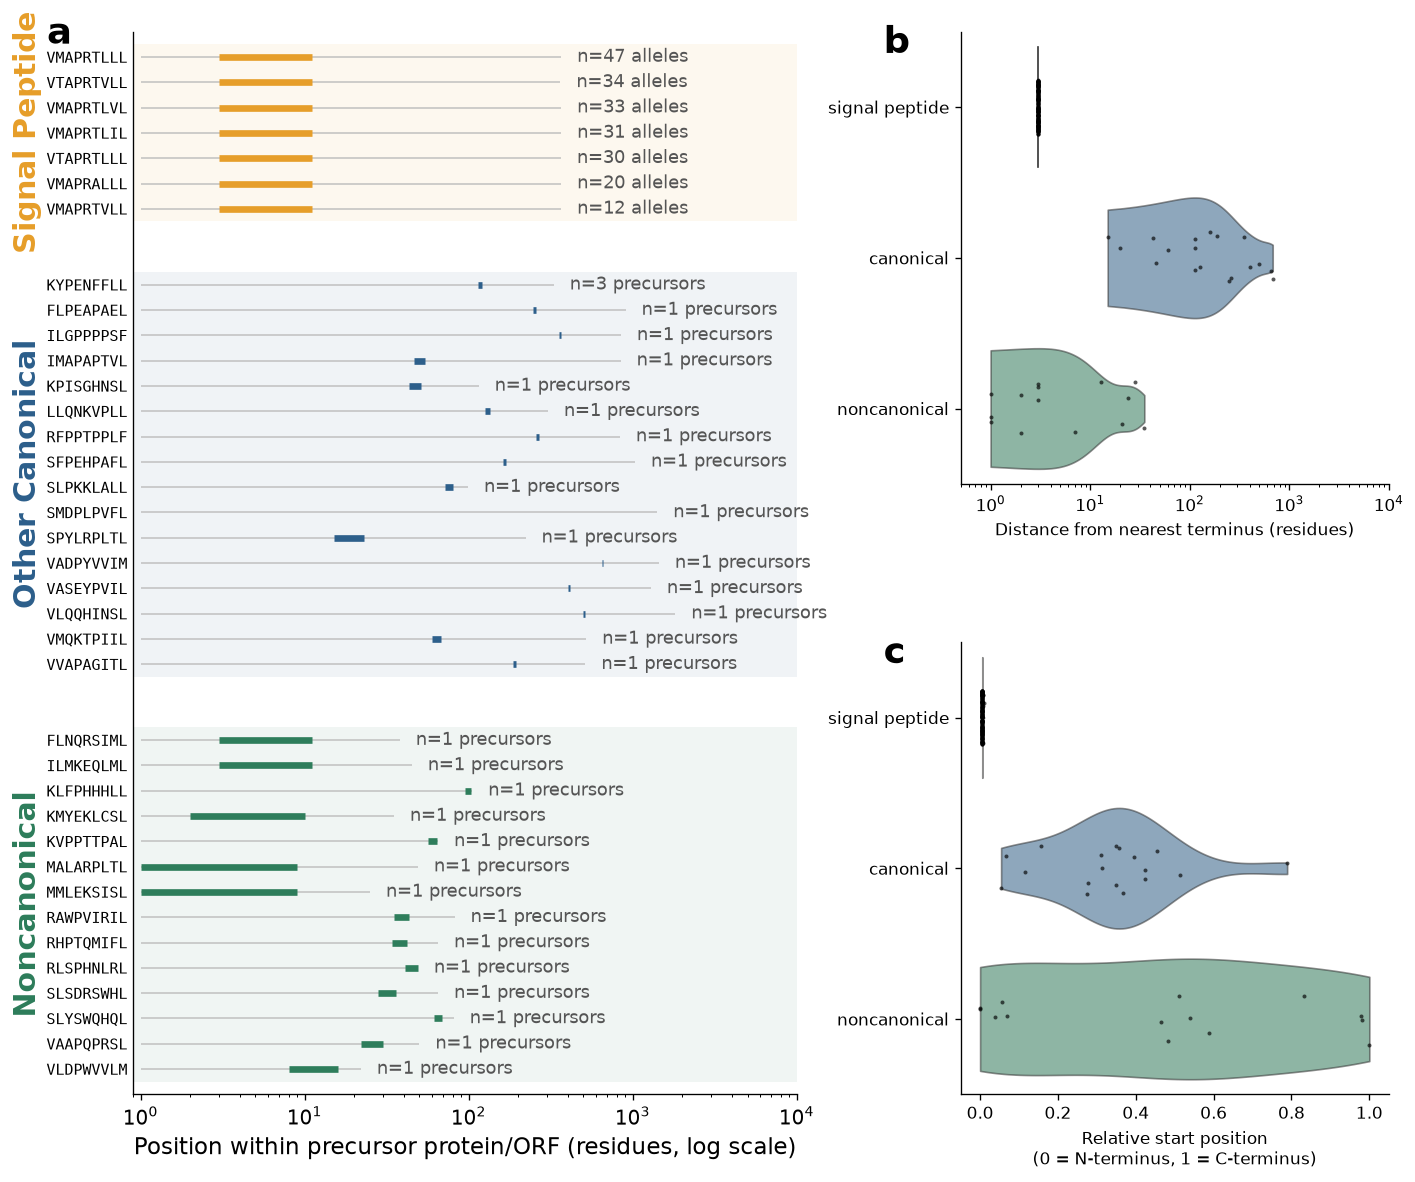

In [5]:

heatmap_display_order_df = (
    heatmap_display_order_df.groupby(['category', 'peptide', 'group_rank'])
    .size()
    .rename('freq')
    .reset_index()
    .sort_values(['group_rank', 'freq', 'peptide'], ascending=[True, False, True])
    .reset_index(drop=True)
)
heatmap_category_orders = {
    category: heatmap_display_order_df.loc[
        heatmap_display_order_df['category'].eq(category),
        'peptide',
    ].tolist()
    for category in ['signal peptide', 'canonical', 'noncanonical']
}


# The recovered-locations CSV may already include derived plotting columns from a previous run.
# Drop them so the notebook can recompute a clean frame without merge-suffix collisions.
derived_plot_cols = [
    'peptide_length',
    'n_term_distance',
    'c_term_distance',
    'min_terminus_distance',
    'relative_start',
    'min_terminus_distance_for_log',
    'y_pos',
    'n_count',
    'count_label',
]
matches_df = matches_df.drop(columns=[col for col in derived_plot_cols if col in matches_df.columns])

matched_only_df = matches_df.loc[matches_df['has_match']].copy()
matched_only_df['peptide_length'] = matched_only_df['peptide'].str.len()
matched_only_df['n_term_distance'] = matched_only_df['start']
matched_only_df['c_term_distance'] = matched_only_df['protein_length'] - matched_only_df['end']
matched_only_df['min_terminus_distance'] = matched_only_df[['n_term_distance', 'c_term_distance']].min(axis=1)
denom = (matched_only_df['protein_length'] - matched_only_df['peptide_length']).replace(0, np.nan)
matched_only_df['relative_start'] = (matched_only_df['start'] / denom).fillna(0.0)

color_map = {
    'signal peptide': '#E69E2A',
    'canonical': '#2D5F8B',
    'noncanonical': '#2E7D5B',
}
category_order = ['signal peptide', 'canonical', 'noncanonical']

# ---- Build per-peptide plotting frame for panel (a): one row per peptide. ----
# For peptides matching multiple precursor proteins, pick the longest match as the
# representative track and annotate the total precursor count on the right.
def _per_peptide_panel(category, count_label):
    sub = matched_only_df.loc[matched_only_df['category'].eq(category)]
    if sub.empty:
        return pd.DataFrame(columns=[
            'peptide', 'category', 'protein_length', 'start', 'end', 'n_count', 'count_label',
        ])
    if category == 'signal peptide':
        n_per_pep = sub.groupby('peptide')['accession'].count().rename('n_count')
    else:
        n_per_pep = sub.groupby('peptide')['accession'].nunique().rename('n_count')
    representative = (
        sub.sort_values(['peptide', 'protein_length'], ascending=[True, False])
        .drop_duplicates('peptide', keep='first')
        .copy()
    )
    representative = representative.merge(n_per_pep, on='peptide')
    representative['category'] = category
    representative['count_label'] = count_label

    category_ordered_peptides = heatmap_category_orders.get(category, [])
    if category_ordered_peptides:
        representative['peptide'] = pd.Categorical(
            representative['peptide'],
            categories=category_ordered_peptides,
            ordered=True,
        )
        representative = representative.loc[representative['peptide'].notna()].sort_values('peptide')
        representative = representative.iloc[::-1].reset_index(drop=True)
        representative['peptide'] = representative['peptide'].astype(str)
    else:
        representative = representative.sort_values('peptide', ascending=False).reset_index(drop=True)

    return representative[['peptide', 'category', 'protein_length', 'start', 'end', 'n_count', 'count_label']]


signal_panel_df = _per_peptide_panel('signal peptide', 'alleles')
canonical_panel_df = _per_peptide_panel('canonical', 'precursors')
noncanonical_panel_df = _per_peptide_panel('noncanonical', 'precursors')

# Stack groups bottom-to-top with a gap between them so panels read like the section4 heatmap.
GAP_ROWS = 2
group_dfs_in_plot_order = [
    ('noncanonical', noncanonical_panel_df),
    ('canonical', canonical_panel_df),
    ('signal peptide', signal_panel_df),
]

panel_a_df_parts = []
group_y_ranges = {}
y_cursor = 0
for cat, sub in group_dfs_in_plot_order:
    if sub.empty:
        continue
    sub = sub.copy()
    sub['y_pos'] = np.arange(y_cursor, y_cursor + len(sub))
    panel_a_df_parts.append(sub)
    group_y_ranges[cat] = (y_cursor, y_cursor + len(sub) - 1)
    y_cursor += len(sub) + GAP_ROWS

panel_a_df = pd.concat(panel_a_df_parts, ignore_index=True)
panel_a_lookup_df = panel_a_df[['peptide', 'category', 'y_pos', 'n_count', 'count_label']].drop_duplicates()

location_export_df = matched_only_df.merge(
    panel_a_lookup_df,
    on=['peptide', 'category'],
    how='left',
)
location_export_df = location_export_df.sort_values(
    ['category', 'y_pos', 'peptide', 'accession', 'start', 'end']
).reset_index(drop=True)

group_display_label = {
    'signal peptide': 'Signal Peptide',
    'canonical': 'Other Canonical',
    'noncanonical': 'Noncanonical',
}

n_signal = matched_only_df.loc[matched_only_df['category'].eq('signal peptide'), 'peptide'].nunique()
n_canonical = matched_only_df.loc[matched_only_df['category'].eq('canonical'), 'peptide'].nunique()
n_noncanonical = matched_only_df.loc[matched_only_df['category'].eq('noncanonical'), 'peptide'].nunique()

# ---- Figure layout ----
mpl.rcParams.update({'font.family': 'DejaVu Sans'})
fig = plt.figure(figsize=(13.5, 11.5), dpi=120)
gs = GridSpec(
    2, 2,
    width_ratios=[1.55, 1.0],
    height_ratios=[1, 1],
    wspace=0.30,
    hspace=0.35,
    figure=fig,
)
ax_a = fig.add_subplot(gs[:, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 1])

# ---- Panel (a): peptide spans on log-scale precursor position ----
for _, row in panel_a_df.iterrows():
    y = row['y_pos']
    color = color_map[row['category']]
    ax_a.hlines(y, 1, max(row['protein_length'], 1.01),
                color='#BFBFBF', linewidth=0.9, zorder=1)
    ax_a.hlines(y, max(row['start'] + 1, 1), max(row['end'], row['start'] + 1.001),
                color=color, linewidth=4.0, zorder=3)
    if pd.notna(row['n_count']) and row['n_count'] > 0:
        ax_a.text(
            row['protein_length'] * 1.25, y,
            f"n={int(row['n_count'])} {row['count_label']}",
            va='center', ha='left', fontsize=11, color='#555',
        )

# Background tint + LEFT vertical group label per category, mirroring the section4 heatmap.
for cat, (y_min_idx, y_max_idx) in group_y_ranges.items():
    y_min = y_min_idx - 0.5
    y_max = y_max_idx + 0.5
    ax_a.axhspan(y_min, y_max, facecolor=color_map[cat], alpha=0.07, zorder=0)
    ax_a.text(
        -0.16, (y_min + y_max) / 2,
        group_display_label[cat],
        transform=ax_a.get_yaxis_transform(),
        ha='center', va='center',
        rotation=90,
        fontsize=18, fontweight='bold', color=color_map[cat],
    )

ax_a.set_yticks(panel_a_df['y_pos'].values)
ax_a.set_yticklabels(panel_a_df['peptide'].values, fontsize=9, family='DejaVu Sans Mono')
ax_a.set_xscale('log')
ax_a.set_xlim(0.9, 1e4)
ax_a.set_ylim(panel_a_df['y_pos'].min() - 1, panel_a_df['y_pos'].max() + 1)
ax_a.set_xlabel('Position within precursor protein/ORF (residues, log scale)', fontsize=14)
ax_a.tick_params(axis='y', length=0)
ax_a.tick_params(axis='x', labelsize=12)
for spine in ('top', 'right'):
    ax_a.spines[spine].set_visible(False)

# ---- Panel (b): distance from nearest terminus, log scale ----
matched_only_df['min_terminus_distance_for_log'] = matched_only_df['min_terminus_distance'] + 1

sns.violinplot(
    data=matched_only_df,
    y='category', x='min_terminus_distance_for_log',
    order=category_order, hue='category', hue_order=category_order,
    palette=color_map, legend=False,
    inner=None, ax=ax_b, cut=0, linewidth=1.0, saturation=0.9,
)
for collection in ax_b.collections:
    collection.set_alpha(0.55)
sns.stripplot(
    data=matched_only_df,
    y='category', x='min_terminus_distance_for_log',
    order=category_order, color='black',
    size=2.4, alpha=0.65, jitter=0.18, ax=ax_b,
)
ax_b.set_xscale('log')
ax_b.set_xlim(0.5, 1e4)
ax_b.set_xlabel('Distance from nearest terminus (residues)')
ax_b.set_ylabel('')
for spine in ('top', 'right'):
    ax_b.spines[spine].set_visible(False)

# ---- Panel (c): relative start position ----
sns.violinplot(
    data=matched_only_df,
    y='category', x='relative_start',
    order=category_order, hue='category', hue_order=category_order,
    palette=color_map, legend=False,
    inner=None, ax=ax_c, cut=0, linewidth=1.0, saturation=0.9,
)
for collection in ax_c.collections:
    collection.set_alpha(0.55)
sns.stripplot(
    data=matched_only_df,
    y='category', x='relative_start',
    order=category_order, color='black',
    size=2.4, alpha=0.65, jitter=0.18, ax=ax_c,
)
ax_c.set_xlim(-0.05, 1.05)
ax_c.set_xlabel('Relative start position\n(0 = N-terminus, 1 = C-terminus)')
ax_c.set_ylabel('')
for spine in ('top', 'right'):
    ax_c.spines[spine].set_visible(False)

# Panel letters
for ax, letter, x_off in ((ax_a, 'a', -0.13), (ax_b, 'b', -0.18), (ax_c, 'c', -0.18)):
    ax.text(x_off, 1.015, letter, transform=ax.transAxes,
            fontsize=22, fontweight='bold', va='top', ha='left')

# ---- Save ----
output_stem = os.path.join(fig_dir, 'fig_peptide_locations')
fig.savefig(output_stem + '.png', dpi=600, bbox_inches='tight')
fig.savefig(output_stem + '.pdf', bbox_inches='tight')
plt.show()
